In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [180]:
df = pd.read_csv("capstone_project.csv")
df.head()

,Timestamp,1. How old are you?,2. What is your employment status?,3. What is your approximate monthly income?,4. Where are you currently based?,5. Do you currently have medical aid?,6. Have you heard of NMC (Namibia Medical Care),"7. If yes, which of the NMC options have you heard of (Select all that apply)\n\nSKIP IF YOU ANSWERED NO OR NOT SURE IN Q6",8. How would you describe your overall impression of NMC?\n\nSKIP IF YOU ANSWERED NO OR NOT SURE IN Q6,9.. Do you know roughly what medical aid costs per month?,"10. If you do not have medical aid, why not (Select all that apply)\n\nSKIP TO Q15 IF YOU HAVE MEDICAL AID","12. How likely are you to get medical aid in the next 12 months (Skip if you have medical aid)\n1= Not at all likely, 5= Very likely",13. What would most likely make you sign up? (Select all that apply and skip if you have medical aid),14. How much would you be willing to pay per month for medical aid? (Skip if you have medical aid),15. Which benefits matter most to you? (Select your top 3),"16. In one or two sentences, why do you think young Namibians avoid medical aid?"
0,2026/03/26 11:51:41 AM GMT+2,25-30,Employed full-time,"N$10,000 - N$25,000",Khomas Region,Yes,Yes,Jade,Somewhat positive,I have heard figures but I am not sure,Other,1 - Not all likely,Lower monthly cost;A better understanding of t...,"N$500 - N$1,000",Doctor visits;Hospitalisation;Optical;Maternit...,Because of lack of funds and lack of understan...
1,2026/03/26 12:00:01 PM GMT+2,25-30,Employed full-time,"N$5,000 - N$10,000",Khomas Region,Yes,Yes,Ruby,Somewhat positive,"Yes, I have a good idea",Other,NaN,Other,I would not pay for it at all,Doctor visits;Chronic medication;Dental,It’s not affordable
2,2026/03/26 12:03:57 PM GMT+2,31-35,Employed full-time,"Above N$20,000",Khomas Region,Yes,Yes,Topaz;Topaz Plus;Emerald;Amber;Opal;Jade;Ruby;...,Very positive,"Yes, I have a good idea",NaN,NaN,Lower monthly cost;My employer covering part o...,"N$1,000 - N$2,000",Doctor visits;Hospitalisation;Chronic medicati...,Lower monthly cost
3,2026/03/26 12:10:06 PM GMT+2,25-30,Employed full-time,"N$5,000 - N$10,000",Khomas Region,No,Yes,Emerald Plus,Very positive,I have heard figures but I am not sure,My employer does not offer it,5 - Very likely,Lower monthly cost;My employer covering part o...,"N$500 - N$1,000",Doctor visits;Hospitalisation;Dental;Optical;M...,"I’d say they don’t avoid it, they are just not..."
4,2026/03/26 12:47:37 PM GMT+2,25-30,Employed full-time,"Above N$20,000",Khomas Region,Yes,No,NaN,NaN,"Yes, I have a good idea",NaN,NaN,Lower monthly cost,NaN,Doctor visits,Most of them can not afford


In [181]:
df.shape

(553, 16)

In [182]:
df.info

<bound method DataFrame.info of                         Timestamp 1. How old are you?   \
0    2026/03/26 11:51:41 AM GMT+2                25-30   
1    2026/03/26 12:00:01 PM GMT+2                25-30   
2    2026/03/26 12:03:57 PM GMT+2                31-35   
3    2026/03/26 12:10:06 PM GMT+2                25-30   
4    2026/03/26 12:47:37 PM GMT+2                25-30   
..                            ...                  ...   
548   2026/04/09 5:44:25 PM GMT+2                18-24   
549   2026/04/09 7:54:50 PM GMT+2                31-35   
550   2026/04/09 9:24:27 PM GMT+2                31-35   
551   2026/04/09 9:53:24 PM GMT+2                25-30   
552  2026/04/09 10:04:36 PM GMT+2                18-24   

    2. What is your employment status?  \
0                   Employed full-time   
1                   Employed full-time   
2                   Employed full-time   
3                   Employed full-time   
4                   Employed full-time   
..                 

In [183]:
df.isnull().sum()

Timestamp                                                                                                                                  0
1. How old are you?                                                                                                                        0
2. What is your employment status?                                                                                                         0
3. What is your approximate monthly income?                                                                                                0
4. Where are you currently based?                                                                                                          0
5. Do you currently have medical aid?                                                                                                      0
6. Have you heard of NMC (Namibia Medical Care)                                                                                            0
7. If yes, wh

In [184]:
df.columns.tolist()
#show all column names as a list to see what we are working with

['Timestamp',
 '1. How old are you? ',
 '2. What is your employment status?',
 '3. What is your approximate monthly income?',
 '4. Where are you currently based?',
 '5. Do you currently have medical aid?',
 '6. Have you heard of NMC (Namibia Medical Care)',
 '7. If yes, which of the NMC options have you heard of (Select all that apply)\n\nSKIP IF YOU ANSWERED NO OR NOT SURE IN Q6',
 '8. How would you describe your overall impression of NMC?\n\nSKIP IF YOU ANSWERED NO OR NOT SURE IN Q6',
 '9.. Do you know roughly what medical aid costs per month?',
 '10. If you do not have medical aid, why not (Select all that apply)\n\nSKIP TO Q15 IF YOU HAVE MEDICAL AID',
 '12. How likely are you to get medical aid in the next 12 months (Skip if you have medical aid)\n1= Not  at all likely, 5= Very likely',
 '13. What would most likely make you sign up? (Select all that apply and skip if you have medical aid)',
 '14. How much would you be willing to pay per month for medical aid? (Skip if you have med

In [185]:
# Rename all columns to short clean names that are easier to work with
df.columns = [
    'timestamp',
    'age',
    'employment',
    'income',
    'location',
    'has_medical_aid',
    'heard_of_nmc',
    'nmc_products_known',
    'nmc_impression',
    'knows_cost',
    'why_no_medical_aid',
    'likelihood_to_sign_up',
    'what_would_make_sign_up',
    'willingness_to_pay',
    'benefits_wanted',
    'open_text'
]

# Check that the rename worked
df.columns.tolist()

['timestamp',
 'age',
 'employment',
 'income',
 'location',
 'has_medical_aid',
 'heard_of_nmc',
 'nmc_products_known',
 'nmc_impression',
 'knows_cost',
 'why_no_medical_aid',
 'likelihood_to_sign_up',
 'what_would_make_sign_up',
 'willingness_to_pay',
 'benefits_wanted',
 'open_text']

In [186]:
# Drop the timestamp column because it is not useful for our analysis
df = df.drop(columns=['timestamp'])

# Check the shape to confirm one column was removed
df.shape

(553, 15)

In [187]:
# Loop through each column and print its unique values
for col in df.columns:
    print(col)
    print(df[col].unique())
    print()

age
['25-30' '31-35' '18-24' 'Prefer not to say']

employment
['Employed full-time' 'Unemployed' 'Student' 'Self-employed'
 'Employed part-tim']

income
['N$10,000 - N$25,000' 'N$5,000 - N$10,000' 'Above N$20,000'
 'Under N$5,000' 'Prefer not to say']

location
['Khomas Region' 'Other urban area' 'Rural area']

has_medical_aid
['Yes' 'No' 'Not sure']

heard_of_nmc
['Yes' 'No' 'Maybe']

nmc_products_known
['Jade' 'Ruby'
 'Topaz;Topaz Plus;Emerald;Amber;Opal;Jade;Ruby;Emerald Plus;Amber Plus'
 'Emerald Plus' nan 'None of the above' 'Topaz' 'Topaz Plus'
 'Topaz;Amber;Jade;Ruby' 'Emerald' 'Opal' 'Topaz;Topaz Plus;Emerald;Amber'
 'Emerald;Amber;Jade' 'Topaz;Topaz Plus;Opal;Ruby'
 'Topaz;Topaz Plus;Emerald;Amber;Opal' 'Amber'
 'Topaz;Topaz Plus;Jade;Ruby' 'Emerald;Amber Plus'
 'Topaz;Topaz Plus;Emerald;Amber;Opal;Jade;Ruby' 'Emerald;Amber;Ruby'
 'Amber;Jade;Ruby' 'Amber Plus' 'Emerald;Opal' 'Amber;Ruby;Amber Plus'
 'Topaz;Topaz Plus' 'Topaz;Emerald;Jade;Ruby'
 'Jade;Ruby;Emerald Plus;Amber P

In [188]:
# Check the unique values in the likelihood to sign up column
df['likelihood_to_sign_up'].unique()

array(['1 - Not all likely', nan, '5 - Very likely', '2 -', '3 - Neutral',
       '4', '4;5 - Very likely', '1 - Not all likely;3 - Neutral',
       '2 -;3 - Neutral', '3 - Neutral;4'], dtype=object)

In [189]:
# Extract just the first number from the likelihood column and convert it to a number
# The .str[0] gets the first character, and pd.to_numeric converts it to a number
# errors='coerce' turns anything that can't be converted into NaN
df['likelihood_to_sign_up'] = pd.to_numeric(df['likelihood_to_sign_up'].str[0], errors='coerce')

# Check the unique values to confirm it worked
df['likelihood_to_sign_up'].unique()

array([ 1., nan,  5.,  2.,  3.,  4.])

In [190]:
# Check unique values for the has_medical_aid column
print(df['has_medical_aid'].unique())
print()

# Check unique values for the heard_of_nmc column
print(df['heard_of_nmc'].unique())
print()

# Check unique values for the nmc_impression column
print(df['nmc_impression'].unique())
print()

# Check unique values for the knows_cost column
print(df['knows_cost'].unique())
print()

# Check unique values for the willingness_to_pay column
print(df['willingness_to_pay'].unique())

['Yes' 'No' 'Not sure']

['Yes' 'No' 'Maybe']

['Somewhat positive' 'Very positive' nan 'Neutral' 'Somewhat negative'
 'I have never heard of them']

['I have heard figures but I am not sure' 'Yes, I have a good idea'
 'No, I have no idea' nan]

['N$500 - N$1,000' 'I would not pay for it at all' 'N$1,000 - N$2,000' nan
 'Under N$500' 'Above N$2,000']


In [191]:
# Check unique values for age, employment, income, and location
print(df['age'].unique())
print()
print(df['employment'].unique())
print()
print(df['income'].unique())
print()
print(df['location'].unique())

['25-30' '31-35' '18-24' 'Prefer not to say']

['Employed full-time' 'Unemployed' 'Student' 'Self-employed'
 'Employed part-tim']

['N$10,000 - N$25,000' 'N$5,000 - N$10,000' 'Above N$20,000'
 'Under N$5,000' 'Prefer not to say']

['Khomas Region' 'Other urban area' 'Rural area']


In [192]:
# Fix the truncated 'Employed part-tim' value to 'Employed part-time'
df['employment'] = df['employment'].replace('Employed part-tim', 'Employed part-time')

# Confirm the fix worked
df['employment'].unique()

array(['Employed full-time', 'Unemployed', 'Student', 'Self-employed',
       'Employed part-time'], dtype=object)

In [193]:
#count how many people have medical aid and how many don't
df["has_medical_aid"].value_counts()

has_medical_aid
No          297
Yes         254
Not sure      2
Name: count, dtype: int64

In [194]:
type(df)

pandas.core.frame.DataFrame

In [195]:
# Reload the data from scratch
df = pd.read_csv('capstone_project.csv')

# Rename all columns
df.columns = [
    'timestamp',
    'age',
    'employment',
    'income',
    'location',
    'has_medical_aid',
    'heard_of_nmc',
    'nmc_products_known',
    'nmc_impression',
    'knows_cost',
    'why_no_medical_aid',
    'likelihood_to_sign_up',
    'what_would_make_sign_up',
    'willingness_to_pay',
    'benefits_wanted',
    'open_text'
]

# Drop timestamp
df = df.drop(columns=['timestamp'])

# Fix truncated employment value
df['employment'] = df['employment'].replace('Employed part-tim', 'Employed part-time')

# Clean likelihood column to extract just the number
df['likelihood_to_sign_up'] = pd.to_numeric(df['likelihood_to_sign_up'].str[0], errors='coerce')

# Remove the one Not sure row
df = df[df['has_medical_aid'] != 'Not sure']

# Confirm it worked
print(type(df))
print(df.shape)
df['has_medical_aid'].value_counts()

<class 'pandas.core.frame.DataFrame'>
(551, 15)


has_medical_aid
No     297
Yes    254
Name: count, dtype: int64

In [196]:
# save cleaned dataframe as nee csv file
df.to_csv("NMC_survey_cleaned.csv", index=False)

/var/folders/v4/mywm67ld6xz22gvktd9kg3000000gn/T/ipykernel_30368/1482607026.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="has_medical_aid", palette="Blues")


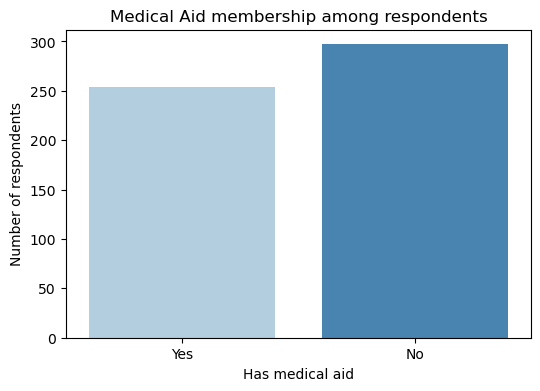

In [197]:
# set the chart size so it is not too small
plt.figure(figsize=(6, 4))

#create a count plot showing how many people have medical aid vs those who dont
sns.countplot(data=df, x="has_medical_aid", palette="Blues")

#add title and axis labels
plt.title('Medical Aid membership among respondents')
plt.xlabel('Has medical aid')
plt.ylabel('Number of respondents')

plt.show()           

/var/folders/v4/mywm67ld6xz22gvktd9kg3000000gn/T/ipykernel_30368/3268253832.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="age", palette="Blues",


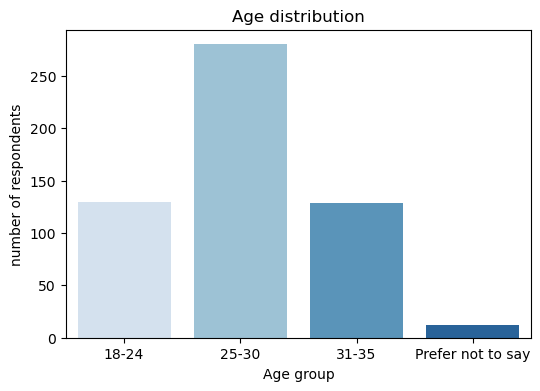

In [198]:
#set chart size
plt.figure(figsize=(6, 4))
#create a count plot to show age breakdown
sns.countplot(data=df, x="age", palette="Blues",
              order=["18-24", "25-30", "31-35", "Prefer not to say"])

plt.title("Age distribution")
plt.xlabel("Age group")
plt.ylabel("number of respondents")


plt.show()

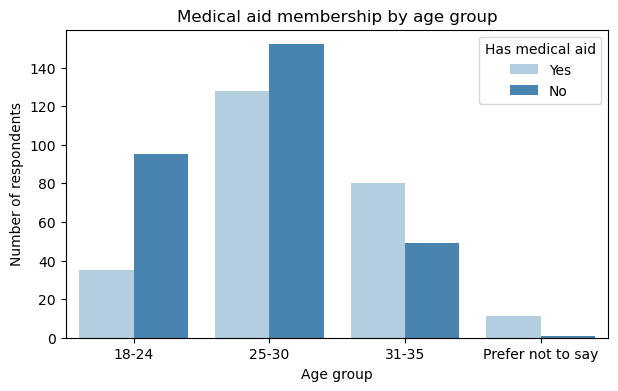

In [199]:
plt.figure(figsize=(7, 4))

sns.countplot(data=df, x="age", hue="has_medical_aid", palette="Blues",
              order=["18-24", "25-30", "31-35", "Prefer not to say"])

plt.title("Medical aid membership by age group")
plt.xlabel("Age group")
plt.ylabel("Number of respondents")

plt.legend(title="Has medical aid", bbox_to_anchor=(1, 1))

plt.show()

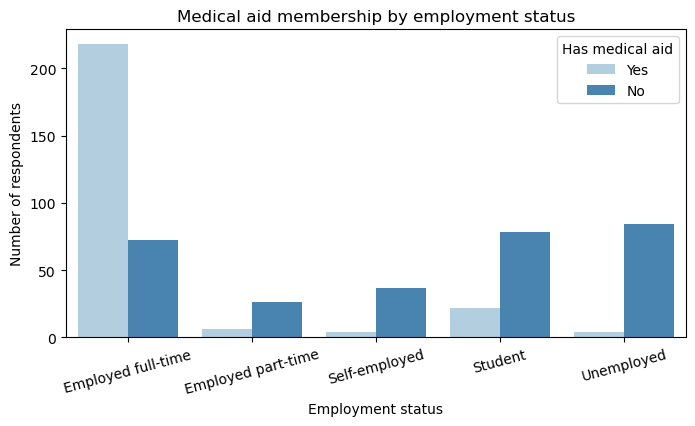

In [200]:
plt.figure(figsize=(8, 4))

sns.countplot(data=df, x="employment", hue="has_medical_aid", palette="Blues",
              order=["Employed full-time", "Employed part-time", "Self-employed", "Student", "Unemployed"])

plt.title("Medical aid membership by employment status")
plt.xlabel("Employment status")
plt.ylabel("Number of respondents")

plt.xticks(rotation=15)

plt.legend(title="Has medical aid", bbox_to_anchor=(1, 1))

plt.show()

In [201]:
# FINDING: Full-time employed respondents have the highest medical aid membership.
# Students rank second, likely because they are still covered under their parents' plans.
# Self-employed and part-time workers have low coverage despite having income, suggesting individual premiums are unaffordable without employer contributions.
# Unemployed respondents have almost no coverage at all.

In [202]:
# Check exact unique values in the income column
df['income'].unique()

array(['N$10,000 - N$25,000', 'N$5,000 - N$10,000', 'Above N$20,000',
       'Under N$5,000', 'Prefer not to say'], dtype=object)

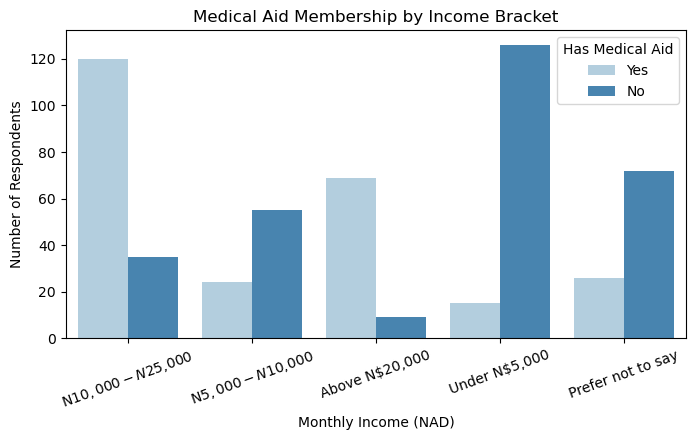

In [203]:
# Set the chart size
plt.figure(figsize=(8, 4))

# Create a count plot with no order specified to see all bars
sns.countplot(data=df, x='income', hue='has_medical_aid', palette='Blues')

# Add a title and axis labels
plt.title('Medical Aid Membership by Income Bracket')
plt.xlabel('Monthly Income (NAD)')
plt.ylabel('Number of Respondents')

# Rotate the x-axis labels so they do not overlap
plt.xticks(rotation=20)

# Move the legend outside the chart
plt.legend(title='Has Medical Aid', bbox_to_anchor=(1, 1))

# Display the chart
plt.show()

In [204]:
# FINDING: Medical aid membership increases with income.
# The Under N$5,000 group is the largest segment and has almost no coverage, suggesting affordability is a structural barrier, not just a communications gap.
# Note: income brackets overlap between N$10,000-N$25,000 and Above N$20,000.
# These will be merged during feature engineering to avoid ambiguity.

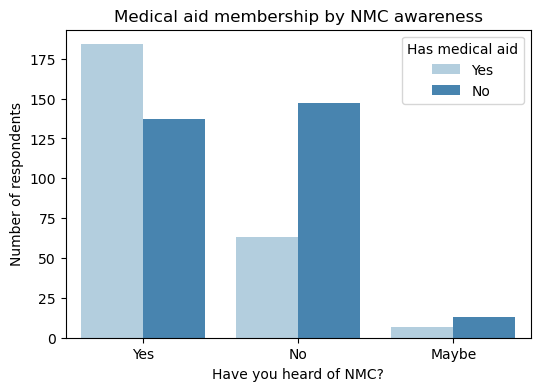

In [205]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="heard_of_nmc", hue="has_medical_aid", palette="Blues",
             order=["Yes", "No", "Maybe"])

plt.title("Medical aid membership by NMC awareness")
plt.xlabel("Have you heard of NMC?")
plt.ylabel("Number of respondents")

plt.legend(title="Has medical aid", bbox_to_anchor=(1, 1))


plt.show()

In [206]:
# FINDING: NMC awareness does not strongly predict medical aid membership.
# A significant portion of people with medical aid have never heard of NMC, suggesting they are with competitor funds.
# Awareness and conversion are two separate challenges for NMC.

/var/folders/v4/mywm67ld6xz22gvktd9kg3000000gn/T/ipykernel_30368/563168145.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=no_medical_aid, x="likelihood_to_sign_up", palette="Blues")


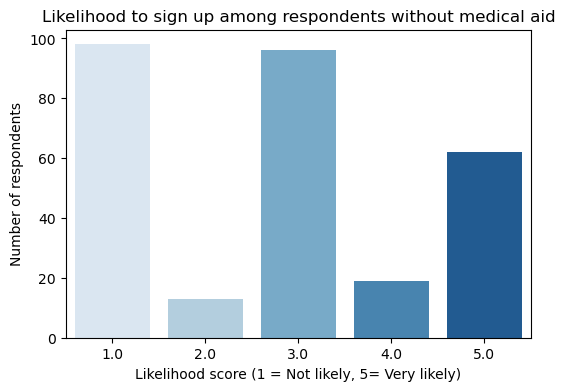

In [207]:
no_medical_aid = df[df["has_medical_aid"] == "No" ]

plt.figure(figsize=(6, 4))

sns.countplot(data=no_medical_aid, x="likelihood_to_sign_up", palette="Blues")

plt.title("Likelihood to sign up among respondents without medical aid")
plt.xlabel("Likelihood score (1 = Not likely, 5= Very likely)")
plt.ylabel("Number of respondents")


plt.show()

In [208]:
# FINDING: Among uninsured respondents, 60 are unlikely to sign up,
# 55 are neutral, and 29 are very likely to sign up.
# The neutral group represents the highest conversion opportunity for NMC  as they are undecided and potentially persuadable with the right messaging.

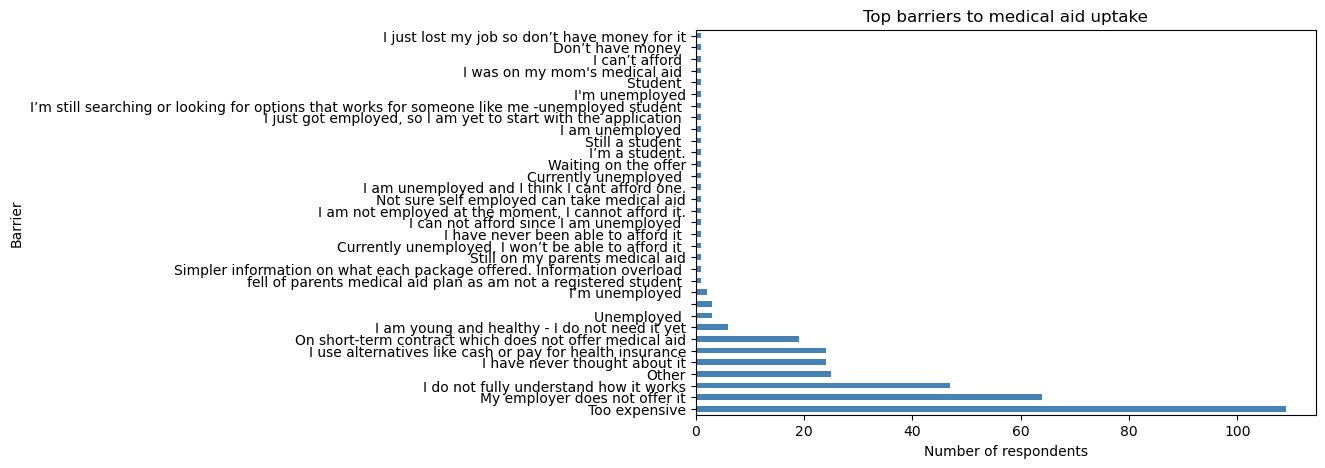

In [209]:
#filter only the people without medical aid
no_aid=df[df["has_medical_aid"] == "No" ]

#splits the multiple choice questions and count each individual barrier
barriers = no_aid["why_no_medical_aid"].dropna().str.split(";").explode()

barrier_counts = barriers.value_counts()

plt.figure(figsize=(8, 5))

barrier_counts.plot(kind="barh", color="steelblue")

plt.title("Top barriers to medical aid uptake")
plt.xlabel("Number of respondents")
plt.ylabel("Barrier")


plt.show()

In [210]:
# FINDING: The top three barriers to medical aid uptake are:
# 1. Cost - too expensive (dominant barrier)
# 2. Employer does not offer it - suggests NMC needs a B2B employer strategy
# 3. Lack of understanding - a communications problem that marketing can solve

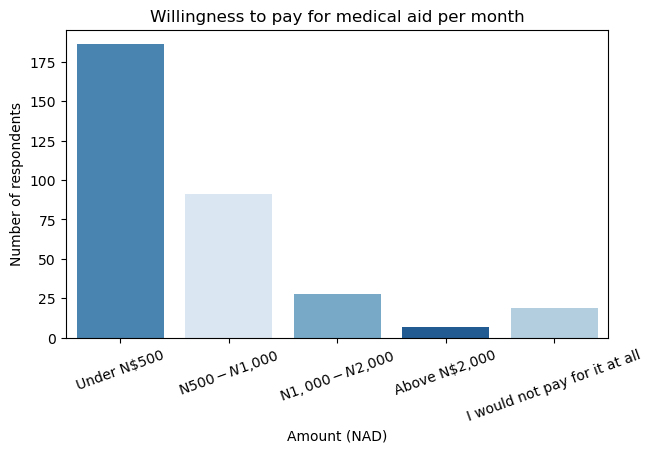

In [211]:
plt.figure(figsize=(7, 4))

sns.countplot(data=df, x='willingness_to_pay', hue='willingness_to_pay', legend=False, palette='Blues',
              order=['Under N$500', 'N$500 - N$1,000', 'N$1,000 - N$2,000', 
                     'Above N$2,000', 'I would not pay for it at all'])

plt.title("Willingness to pay for medical aid per month")
plt.xlabel("Amount (NAD)")
plt.ylabel("Number of respondents")


plt.xticks(rotation=20)

plt.show()

In [212]:
# FINDING: The majority of respondents are willing to pay under N$500 per month, but NMC's cheapest plan starts at approximately N$700.
# This price gap represents a significant barrier to conversion.
# The N$500 - N$1,000 bracket is the most realistic target segment as it aligns closest to NMC's entry level pricing.

In [213]:
df_model = df.copy()

#convert target column to a number - Yes becomes 1 and No becomes 0

df_model["has_medical_aid"] = df_model["has_medical_aid"].map({"Yes": 1, "No": 0})

df_model["has_medical_aid"].value_counts()

has_medical_aid
0    297
1    254
Name: count, dtype: int64

In [214]:
#select columns to encode
cols_to_encode = ["age", "employment", "income", "location", "heard_of_nmc", 
                  "nmc_impression", "knows_cost", "willingness_to_pay"]


#apply one-hot encoding to those columns
#drop_first=True removes one category per column to avoid redundancy
df_model = pd.get_dummies(df_model, columns=cols_to_encode, drop_first=True)

print(df_model.shape)

(551, 32)


In [215]:
#drop columns not bein used rn
df_model = df_model.drop(columns=["why_no_medical_aid", "what_would_make_sign_up",
                                  "benefits_wanted", "open_text", "nmc_products_known",
                                  "likelihood_to_sign_up"])

print(df_model.shape)

df_model.isnull().sum()

(551, 26)


has_medical_aid                                     0
age_25-30                                           0
age_31-35                                           0
age_Prefer not to say                               0
employment_Employed part-time                       0
employment_Self-employed                            0
employment_Student                                  0
employment_Unemployed                               0
income_N$10,000 - N$25,000                          0
income_N$5,000 - N$10,000                           0
income_Prefer not to say                            0
income_Under N$5,000                                0
location_Other urban area                           0
location_Rural area                                 0
heard_of_nmc_No                                     0
heard_of_nmc_Yes                                    0
nmc_impression_Neutral                              0
nmc_impression_Somewhat negative                    0
nmc_impression_Somewhat posi

In [216]:
y = df_model["has_medical_aid"]

X = df_model.drop(columns=["has_medical_aid"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (551, 25)
y shape: (551,)


In [217]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (440, 25)
Test set size: (111, 25)


In [218]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report

model_lr = LogisticRegression(random_state=42, max_iter=1000)

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print("Logistic Regression accuracy:", accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Logistic Regression accuracy: 0.9099099099099099
              precision    recall  f1-score   support

           0       0.87      0.96      0.91        54
           1       0.96      0.86      0.91        57

    accuracy                           0.91       111
   macro avg       0.91      0.91      0.91       111
weighted avg       0.91      0.91      0.91       111



<Figure size 500x400 with 0 Axes>

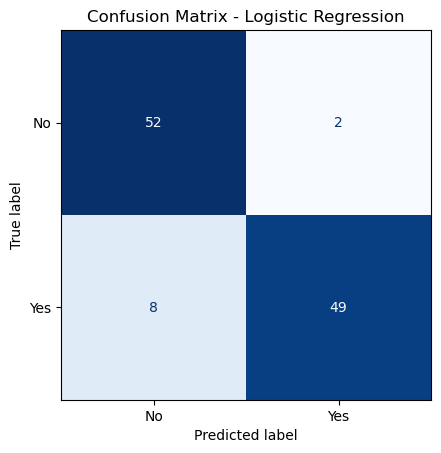

In [219]:

from sklearn.metrics import ConfusionMatrixDisplay


plt.figure(figsize=(5, 4))

# Create and display the confusion matrix for Logistic Regression
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, 
                                         display_labels=['No', 'Yes'],
                                         colorbar=False,
                                         cmap='Blues')


plt.title('Confusion Matrix - Logistic Regression')


plt.show()

In [220]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("Random Forest accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Random Forest accuracy: 0.8828828828828829
              precision    recall  f1-score   support

           0       0.83      0.96      0.89        54
           1       0.96      0.81      0.88        57

    accuracy                           0.88       111
   macro avg       0.89      0.88      0.88       111
weighted avg       0.89      0.88      0.88       111



In [221]:
# RESULT: Random Forest achieved 89% accuracy
# Improved on Logistic Regression across all metrics
# Precision for Yes class improved to 0.90 - model is more confident when predicting Yes
# Still slightly better at predicting No than Yes

<Figure size 500x400 with 0 Axes>

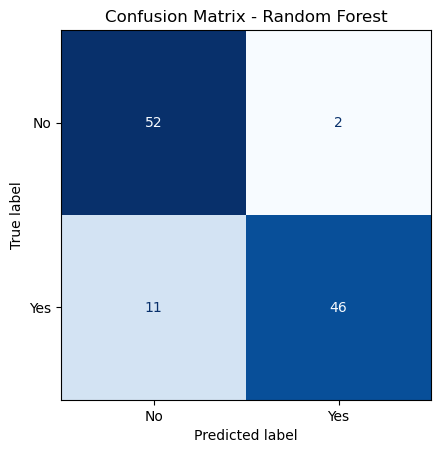

In [222]:

plt.figure(figsize=(5, 4))

# Create and display the confusion matrix for Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf,
                                         display_labels=['No', 'Yes'],
                                         colorbar=False,
                                         cmap='Blues')


plt.title('Confusion Matrix - Random Forest')


plt.show()

In [223]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier (random_state=42, eval_metric="logloss")

model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)

print("XGBoost accuracy:", accuracy_score(y_test, y_pred_xgb))

print(classification_report(y_test, y_pred_xgb))

XGBoost accuracy: 0.918918918918919
              precision    recall  f1-score   support

           0       0.86      1.00      0.92        54
           1       1.00      0.84      0.91        57

    accuracy                           0.92       111
   macro avg       0.93      0.92      0.92       111
weighted avg       0.93      0.92      0.92       111



<Figure size 500x400 with 0 Axes>

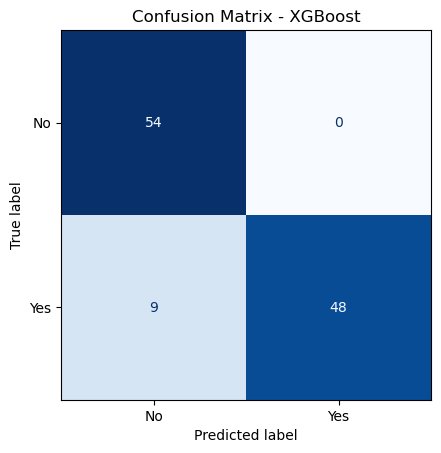

In [224]:

plt.figure(figsize=(5, 4))

# Create and display the confusion matrix for XGBoost
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb,
                                         display_labels=['No', 'Yes'],
                                         colorbar=False,
                                         cmap='Blues')


plt.title('Confusion Matrix - XGBoost')


plt.show()

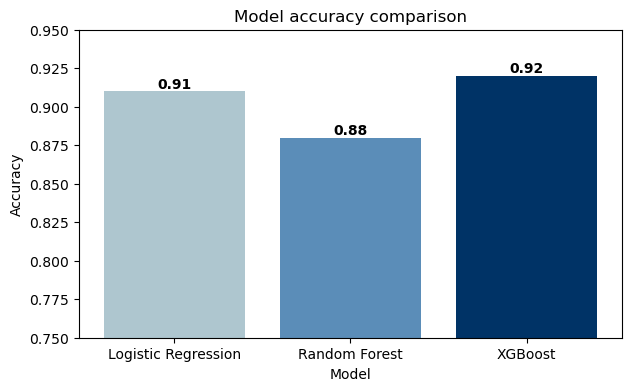

In [225]:
#create a bar chart to compare all three models
models = ["Logistic Regression", "Random Forest", "XGBoost"]
accuracies = [0.91, 0.88, 0.92]

plt.figure(figsize=(7, 4))

plt.bar(models, accuracies, color=["#AEC6CF", "#5B8DB8", "#003366"])

plt.title("Model accuracy comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")


#set y xist to start at 0.75 do difference is visible
plt.ylim(0.75, 0.95)


#accuracy value top of each bar
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.002, str(v), ha="center", fontweight="bold")


plt.show()    

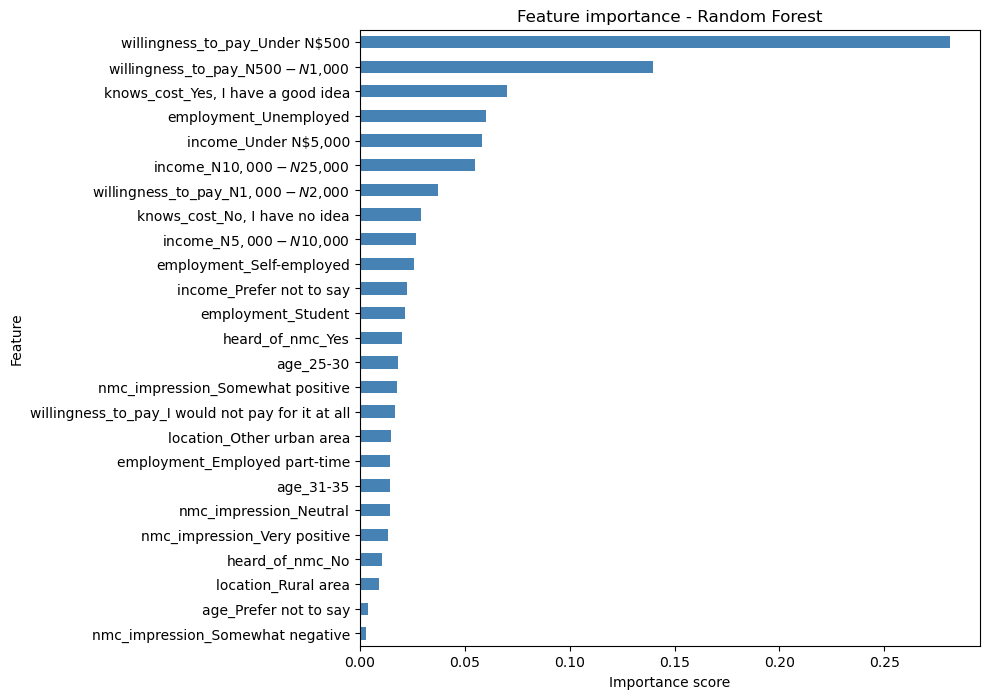

In [226]:
#get feature importance from random forest
importance = pd.Series(model_rf.feature_importances_, index=X.columns)

#set by importance
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(8, 8))

importance.plot(kind="barh", color="steelblue")

plt.title("Feature importance - Random Forest")
plt.xlabel("Importance score")
plt.ylabel("Feature")

plt.show()

In [227]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package stopwords to /Users/rauna/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/rauna/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/rauna/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [228]:
#get open text colum and drop any empty responses
texts = df["open_text"].dropna()

#define a function to clean each response
def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    words = word_tokenize(text)
    stop_words = set(stopwords.words("english"))
    words = [w for w in words if w not in stop_words]
    return words


cleaned_texts = texts.apply(clean_text)

print(cleaned_texts.iloc[0])

['lack', 'funds', 'lack', 'understanding', 'types', 'packages']


In [229]:
import sys
!{sys.executable} -m pip install gensim

In [230]:
from gensim import corpora
from gensim.models import LdaModel

#create dictionary of all unique words across all responses
dictionary = corpora.Dictionary(cleaned_texts)

#convert each response into a bag of words format the model can understand
corpus = [dictionary.doc2bow(text) for text in cleaned_texts]

#train model - asking to find 4 topics
lda_model = LdaModel(corpus=corpus,
                    id2word=dictionary,
                    num_topics=4,
                    random_state=42,
                    passes=10)

for i, topic in lda_model.print_topics(num_words=8):
    print(f"Topic {i}: {topic}")
    print()

Topic 0: 0.089*"expensive" + 0.028*"cost" + 0.023*"high" + 0.022*"medical" + 0.022*"young" + 0.022*"think" + 0.019*"costs" + 0.016*"people"

Topic 1: 0.093*"’" + 0.060*"medical" + 0.050*"aid" + 0.046*"expensive" + 0.020*"think" + 0.018*"costly" + 0.016*"benefits" + 0.012*"afford"

Topic 2: 0.062*"afford" + 0.035*"’" + 0.027*"unemployed" + 0.026*"medical" + 0.024*"cant" + 0.022*"aid" + 0.021*"lack" + 0.017*"understanding"

Topic 3: 0.026*"expensive" + 0.025*"’" + 0.022*"aid" + 0.022*"medical" + 0.020*"avoid" + 0.019*"young" + 0.018*"namibians" + 0.017*"use"



In [231]:
import sys
!{sys.executable} -m pip install textblob

In [232]:
from textblob import TextBlob

#define function that classifies each response as positive, negative or nuetral
def get_sentiment(text):
    #textBlob gives a polarity score between -1 and 1
    score = TextBlob(text).sentiment.polarity
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

#apply sentiment function to evry open text response
df["sentiment"] = df["open_text"].dropna().apply(get_sentiment)

print(df["sentiment"].value_counts())

sentiment
Negative    208
Neutral     200
Positive    143
Name: count, dtype: int64


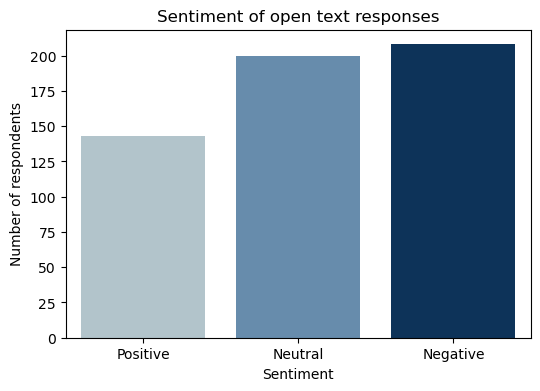

In [233]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="sentiment", hue="sentiment", legend=False,
             palette={"Positive": "#AEC6CF", "Neutral": "#5B8DB8", "Negative": "#003366"},
             order=["Positive", "Neutral", "Negative"])
plt.title("Sentiment of open text responses")
plt.xlabel("Sentiment")
plt.ylabel("Number of respondents")

plt.show()

In [234]:
# Save the cleaned dataset for the dashboard to use
df.to_csv('NMC_survey_cleaned.csv', index=False)

# Save the trained Random Forest model so the dashboard can load it
import joblib
joblib.dump(model_rf, 'model_rf.pkl')

print('Files saved successfully')

Files saved successfully
